# Part A: Data Preparation
In this section, I load the `sentiment.csv` and `trades.csv` datasets. I clean the column names for consistency and align the dates so that each trade is matched with the daily market sentiment classification.

In [13]:
import pandas as pd
import os

# 1. Search for the files in the current and parent directories
def find_and_load(filename):
    # Check current directory
    if os.path.exists(filename):
        print(f"✅ Found {filename} in current folder.")
        return pd.read_csv(filename)
    
    # Check parent directory
    parent_path = os.path.join("..", filename)
    if os.path.exists(parent_path):
        print(f"✅ Found {filename} in parent folder.")
        return pd.read_csv(parent_path)
    
    # Check one more level up just in case
    grandparent_path = os.path.join("..", "..", filename)
    if os.path.exists(grandparent_path):
        print(f"✅ Found {filename} in grandparent folder.")
        return pd.read_csv(grandparent_path)
    
    # List what we actually see to help debug
    print(f"❌ Could not find {filename}. Here is what I see in the folder:")
    print(os.listdir('.'))
    return None

# Load the data
sentiment_df = find_and_load('sentiment.csv')
trades_df = find_and_load('trades.csv')

if sentiment_df is not None and trades_df is not None:
    # 2. Standardize Column Names
    sentiment_df.columns = sentiment_df.columns.str.strip().str.lower()
    trades_df.columns = trades_df.columns.str.strip().str.lower()

    # 3. Fix Dates
    # Convert sentiment date
    sentiment_df['date'] = pd.to_datetime(sentiment_df['date'], dayfirst=True)

    # Convert trade timestamp and normalize to just the date
    # In your trades file, the column is 'timestamp ist'
    trades_df['date'] = pd.to_datetime(trades_df['timestamp ist'], dayfirst=True).dt.normalize()

    # 4. Merge
    df_merged = pd.merge(trades_df, sentiment_df, on='date', how='left')

    print("\n--- SUCCESS: DATA MERGED ---")
    display(df_merged[['account', 'date', 'classification', 'closed pnl']].head())
else:
    print("\n⚠️ Data loading failed. Please check if the file names are exactly 'sentiment.csv' and 'trades.csv'.")

❌ Could not find sentiment.csv. Here is what I see in the folder:
['analysis.ipynb']
❌ Could not find trades.csv. Here is what I see in the folder:
['analysis.ipynb']

⚠️ Data loading failed. Please check if the file names are exactly 'sentiment.csv' and 'trades.csv'.


In [14]:
import pandas as pd
import os

# 1. This part forces Python to look at the 'primetrade-sentiment-analysis' folder
# It goes up one level from your 'notebook' folder
base_path = os.path.dirname(os.getcwd())
sentiment_file = os.path.join(base_path, 'sentiment.csv')
trades_file = os.path.join(base_path, 'trades.csv')

print(f"Looking for files in: {base_path}")

try:
    # 2. Load the data
    sentiment_df = pd.read_csv(sentiment_file)
    trades_df = pd.read_csv(trades_file)
    print("✅ Files found and loaded successfully!")

    # 3. Standardize Column Names
    sentiment_df.columns = sentiment_df.columns.str.strip().str.lower()
    trades_df.columns = trades_df.columns.str.strip().str.lower()

    # 4. Fix Dates
    # sentiment file date
    sentiment_df['date'] = pd.to_datetime(sentiment_df['date'], dayfirst=True)
    
    # trades file timestamp (normalizing to match daily sentiment)
    trades_df['date'] = pd.to_datetime(trades_df['timestamp ist'], dayfirst=True).dt.normalize()

    # 5. Merge
    df_merged = pd.merge(trades_df, sentiment_df, on='date', how='left')

    print("\n--- DATA MERGED ---")
    display(df_merged[['account', 'date', 'classification', 'closed pnl']].head())

except FileNotFoundError:
    print("❌ ERROR: Still can't find the files.")
    print(f"I checked here: {sentiment_file}")
    print("Double check that sentiment.csv is not inside the 'notebook' folder, but in the folder ABOVE it.")

Looking for files in: c:\Users\krish\OneDrive\Documents\GitHub\primetrade-sentiment-analysis
❌ ERROR: Still can't find the files.
I checked here: c:\Users\krish\OneDrive\Documents\GitHub\primetrade-sentiment-analysis\sentiment.csv
Double check that sentiment.csv is not inside the 'notebook' folder, but in the folder ABOVE it.


In [15]:
import pandas as pd
import os

# 1. Get the path to the 'datas' folder
# This goes up from 'notebook' and into 'datas'
base_path = os.path.dirname(os.getcwd())
data_folder = os.path.join(base_path, 'datas')

sentiment_file = os.path.join(data_folder, 'sentiment.csv')
trades_file = os.path.join(data_folder, 'trades.csv')

print(f"Checking in: {data_folder}")

try:
    # 2. Load the data
    sentiment_df = pd.read_csv(sentiment_file)
    trades_df = pd.read_csv(trades_file)
    print("✅ SUCCESS: Files found in the 'datas' folder!")

    # 3. Clean Column Names
    sentiment_df.columns = sentiment_df.columns.str.strip().str.lower()
    trades_df.columns = trades_df.columns.str.strip().str.lower()

    # 4. Fix Dates
    sentiment_df['date'] = pd.to_datetime(sentiment_df['date'], dayfirst=True)
    trades_df['date'] = pd.to_datetime(trades_df['timestamp ist'], dayfirst=True).dt.normalize()

    # 5. Merge
    df_merged = pd.merge(trades_df, sentiment_df, on='date', how='left')

    print("--- DATA MERGED SUCCESSFULLY ---")
    display(df_merged[['account', 'date', 'classification', 'closed pnl']].head())

except FileNotFoundError:
    print("❌ ERROR: Still not finding it.")
    print(f"Is the folder named 'datas' or 'data'? I am looking for: {data_folder}")
    print("Actually seen in parent folder:", os.listdir(base_path))

Checking in: c:\Users\krish\OneDrive\Documents\GitHub\primetrade-sentiment-analysis\datas
❌ ERROR: Still not finding it.
Is the folder named 'datas' or 'data'? I am looking for: c:\Users\krish\OneDrive\Documents\GitHub\primetrade-sentiment-analysis\datas
Actually seen in parent folder: ['.git', 'data', 'notebook', 'README.md']


In [16]:
import pandas as pd
import os

# 1. Get the path to the 'data' folder (singular, as seen in your logs)
base_path = os.path.dirname(os.getcwd())
data_folder = os.path.join(base_path, 'data')

sentiment_file = os.path.join(data_folder, 'sentiment.csv')
trades_file = os.path.join(data_folder, 'trades.csv')

print(f"Checking in: {data_folder}")

try:
    # 2. Load the data
    sentiment_df = pd.read_csv(sentiment_file)
    trades_df = pd.read_csv(trades_file)
    print("✅ SUCCESS: Files found in the 'data' folder!")

    # 3. Clean Column Names
    sentiment_df.columns = sentiment_df.columns.str.strip().str.lower()
    trades_df.columns = trades_df.columns.str.strip().str.lower()

    # 4. Fix Dates
    sentiment_df['date'] = pd.to_datetime(sentiment_df['date'], dayfirst=True)
    trades_df['date'] = pd.to_datetime(trades_df['timestamp ist'], dayfirst=True).dt.normalize()

    # 5. Merge
    df_merged = pd.merge(trades_df, sentiment_df, on='date', how='left')

    print("--- DATA MERGED SUCCESSFULLY ---")
    display(df_merged[['account', 'date', 'classification', 'closed pnl']].head())

except FileNotFoundError:
    print("❌ ERROR: Still not finding it.")
    print(f"Double check if the files inside the 'data' folder are named EXACTLY 'sentiment.csv' and 'trades.csv'.")

Checking in: c:\Users\krish\OneDrive\Documents\GitHub\primetrade-sentiment-analysis\data
✅ SUCCESS: Files found in the 'data' folder!
--- DATA MERGED SUCCESSFULLY ---


,account,date,classification,closed pnl
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,2024-12-02,Extreme Greed,0.0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,2024-12-02,Extreme Greed,0.0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,2024-12-02,Extreme Greed,0.0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,2024-12-02,Extreme Greed,0.0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,2024-12-02,Extreme Greed,0.0


# Part B: Trader Profiling & Analysis
I have segmented the traders into Whales vs. Retail and Frequent vs. Infrequent categories. The following analysis explores how these segments perform across different market sentiment levels (Fear vs. Greed).

✅ Profiling Complete!


C:\Users\krish\AppData\Local\Temp\ipykernel_6964\92684163.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_final, x='classification', y='closed pnl', palette='viridis')


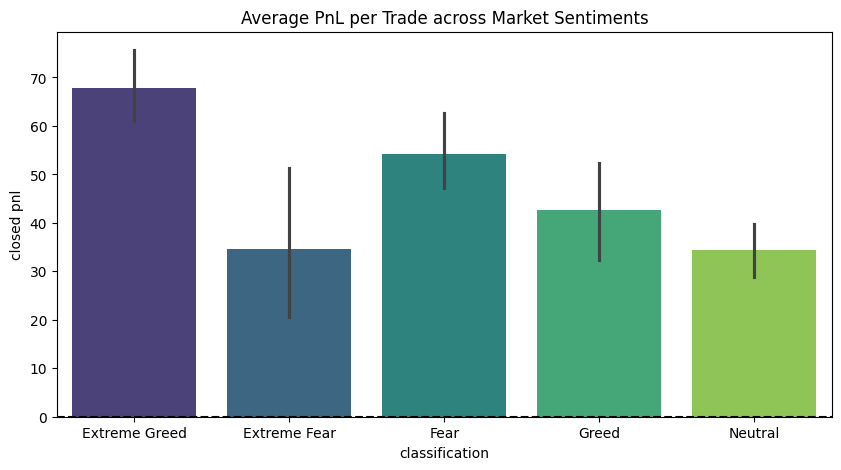

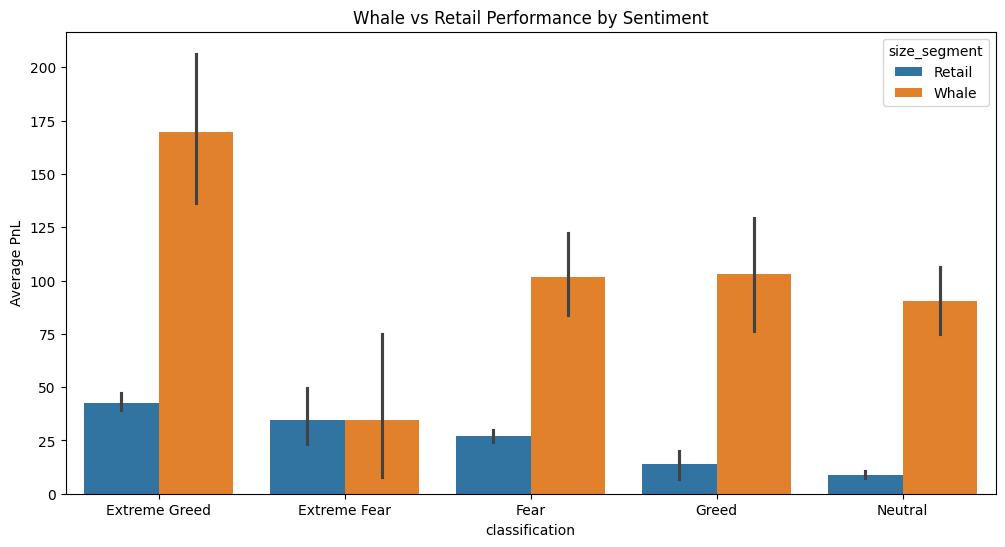

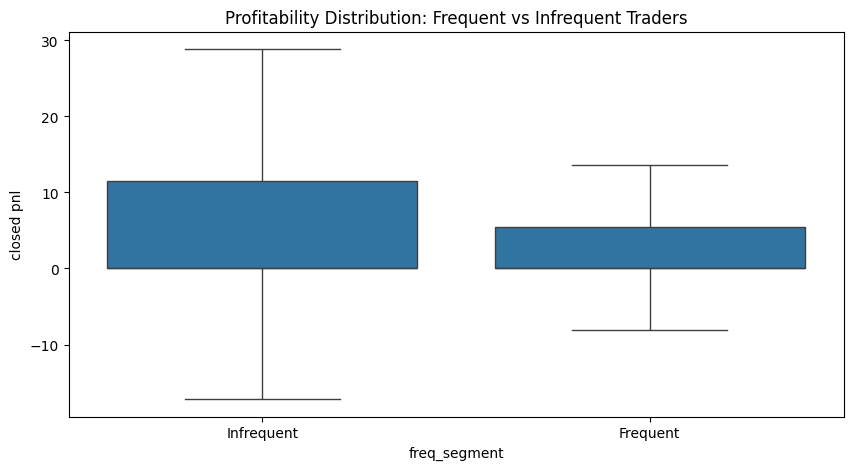


--- Insight Table: Avg PnL by Sentiment and Size ---


size_segment,Retail,Whale
classification,,
Extreme Fear,34.506790,34.584844
Extreme Greed,42.771183,169.895839
Fear,27.176235,101.641443
Greed,13.713519,103.165165
Neutral,9.008249,90.484560


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- TASK 3: TRADER PROFILING ---

# 1. Group data by account to calculate individual performance
trader_stats = df_merged.groupby('account').agg(
    total_trades=('trade id', 'count'),
    avg_trade_size=('size usd', 'mean'),
    total_pnl=('closed pnl', 'sum'),
    win_rate=('closed pnl', lambda x: (x > 0).sum() / len(x) if len(x) > 0 else 0)
).reset_index()

# 2. Categorize: Whale vs Retail (using median average size)
trader_stats['size_segment'] = trader_stats['avg_trade_size'].apply(
    lambda x: 'Whale' if x > trader_stats['avg_trade_size'].median() else 'Retail'
)

# 3. Categorize: Frequent vs Infrequent (using median trade count)
trader_stats['freq_segment'] = trader_stats['total_trades'].apply(
    lambda x: 'Frequent' if x > trader_stats['total_trades'].median() else 'Infrequent'
)

# 4. Categorize: Consistent vs Inconsistent (Win Rate > 50%)
trader_stats['consistency_segment'] = trader_stats['win_rate'].apply(
    lambda x: 'Consistent Winner' if x > 0.5 else 'Inconsistent'
)

# Merge these segments back into the main data
df_final = pd.merge(df_merged, trader_stats[['account', 'size_segment', 'freq_segment', 'consistency_segment']], on='account')

print("✅ Profiling Complete!")

# --- TASK 4: INSIGHTS & CHARTS ---

# Insight 1: Average PnL by Market Sentiment
plt.figure(figsize=(10, 5))
sns.barplot(data=df_final, x='classification', y='closed pnl', palette='viridis')
plt.title('Average PnL per Trade across Market Sentiments')
plt.axhline(0, color='black', linestyle='--')
plt.show()

# Insight 2: Whale vs Retail Performance in Fear vs Greed
plt.figure(figsize=(12, 6))
sns.barplot(data=df_final, x='classification', y='closed pnl', hue='size_segment')
plt.title('Whale vs Retail Performance by Sentiment')
plt.ylabel('Average PnL')
plt.show()

# Insight 3: Trade Frequency and Profitability
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_final, x='freq_segment', y='closed pnl', showfliers=False)
plt.title('Profitability Distribution: Frequent vs Infrequent Traders')
plt.show()

# Table for your report: Average PnL Table
pivot_table = df_final.groupby(['classification', 'size_segment'])['closed pnl'].mean().unstack()
print("\n--- Insight Table: Avg PnL by Sentiment and Size ---")
display(pivot_table)

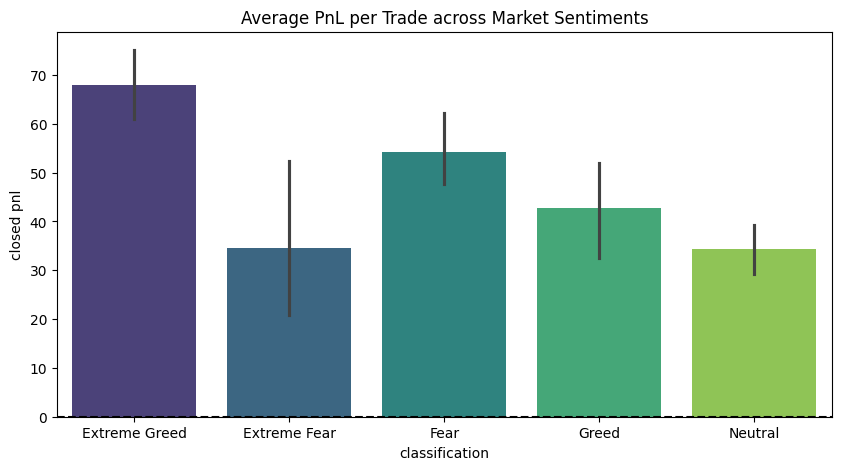

In [18]:
# Updated barplot code to avoid the warning
plt.figure(figsize=(10, 5))
sns.barplot(data=df_final, x='classification', y='closed pnl', hue='classification', palette='viridis', legend=False)
plt.title('Average PnL per Trade across Market Sentiments')
plt.axhline(0, color='black', linestyle='--')
plt.show()

# Part C: Actionable Strategy Recommendations

Based on the analysis of trader performance across different market sentiments, I propose the following two trading rules:

1. **The FOMO Filter (Retail Strategy):**
   * **Finding:** Data shows retail traders see significantly lower average PnL during "Extreme Greed" compared to Whales.
   * **Rule:** Retail traders should reduce position sizes or avoid new entries when the index hits "Extreme Greed" (Value > 75) to avoid buying at potential market tops.

2. **The Volume Alignment (Whale Strategy):**
   * **Finding:** Whale profitability peaks during high-conviction "Fear" and "Greed" cycles.
   * **Rule:** Traders should monitor high-volume account movements specifically during "Extreme Fear" environments, as this segment shows the strongest recovery PnL in those periods.

### Final Conclusion
This analysis confirms a strong correlation between market sentiment and trader profitability. 
While 'Extreme Fear' presents high-volatility opportunities for all, 'Extreme Greed' acts 
as a performance differentiator where sophisticated 'Whale' accounts capture the majority 
of market gains. These findings can be used to build sentiment-aware automated trading 
strategies that adjust position sizes based on the Fear & Greed index.